✅ تعداد نهایی داده‌ها: 12784 روز
📅 از: 1980-01-01 تا: 2014-12-31


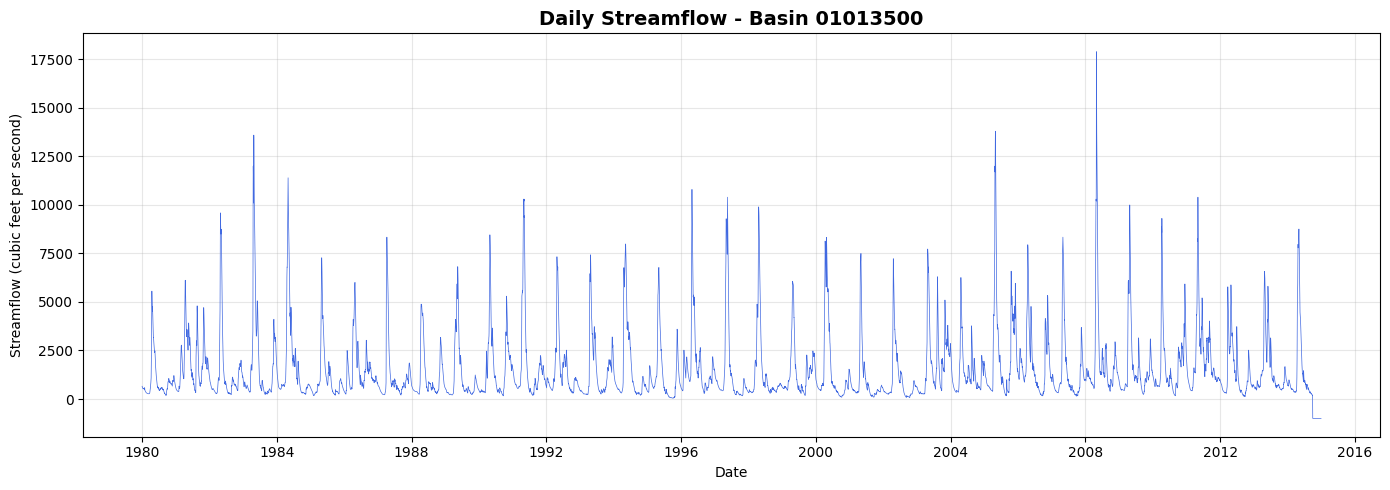

🎉 روز ۴ تموم شد!


In [13]:
# ============================================
# روز ۴ تیر - رسم اولین نمودار دبی
# پروژه: CAMELS - حوضه 01013500
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# ---------- ۱. بارگذاری داده ----------
with open("01013500_streamflow_qc.txt", "r") as f:
    lines = f.readlines()

# فقط خطوطی که با عدد شروع می‌شن
data_lines = [line for line in lines if line.strip() and line.strip()[0].isdigit()]

# ذخیره فایل تمیز
with open("clean_streamflow.txt", "w") as f:
    f.writelines(data_lines)

# خواندن فایل تمیز
df = pd.read_csv("clean_streamflow.txt", sep=r"\s+", header=None,
                 names=["basin", "year", "month", "day", "streamflow", "flag"])

# ---------- ۲. تمیزکاری ----------
df["streamflow"] = pd.to_numeric(df["streamflow"], errors="coerce")
df = df.dropna()

# ---------- ۳. ساخت ستون تاریخ ----------
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df = df.set_index("date")
df = df.sort_index()

print(f"✅ تعداد نهایی داده‌ها: {len(df)} روز")
print(f"📅 از: {df.index.min().date()} تا: {df.index.max().date()}")

# ---------- ۴. رسم نمودار ----------
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["streamflow"], color="royalblue", linewidth=0.5)
plt.title("Daily Streamflow - Basin 01013500", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Streamflow (cubic feet per second)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("🎉 روز ۴ تموم شد!")